In [1]:
import numpy as np
import pickle
import scipy.io
from sklearn.model_selection import train_test_split
import torch

GPU_ENABLED = torch.cuda.is_available()

def set_device(device_id):
    """
    Set the device (CPU or GPU) to be used.
    In Colab, this sets the default torch device globally.
    """
    global GPU_ENABLED
    if device_id >= 0 and torch.cuda.is_available():
        torch.cuda.set_device(device_id)
        print(f"Using GPU: {torch.cuda.get_device_name(device_id)}")
        GPU_ENABLED = True
    else:
        print("Using CPU")
        GPU_ENABLED = False

def gpu_enabled():
    return GPU_ENABLED

def reshape_dataset(train, test):
    X_train, y_train = train
    X_test, y_test = test
    X_train = X_train.reshape((-1, 1, 28, 28)).astype(np.float32) / 255.0
    X_test = X_test.reshape((-1, 1, 28, 28)).astype(np.float32) / 255.0
    y_train = y_train.astype(np.int32)
    y_test = y_test.astype(np.int32)
    return (X_train, y_train), (X_test, y_test)

def save_model(model, filename):
    with open(filename, "wb") as f:
        pickle.dump(model, f)

def load_model(filename):
    with open(filename, "rb") as f:
        model = pickle.load(f)
    return model

def pick(train_set, test_set, n_train, n_test):
    images_train, y_train = train_set
    images_test, y_test = test_set
    train_set = images_train[:n_train], y_train[:n_train]
    test_set = images_test[:n_test], y_test[:n_test]
    return train_set, test_set

def load_hyperspectral(path="/kaggle/input/content/GM01.mat", test_size=0.2, random_state=42):
    mat = scipy.io.loadmat(path)
    data = mat['img'].astype(np.float32)
    labels = mat['map']
    data = data / np.max(data)
    H, W, C = data.shape
    X = data.reshape(-1, C)
    y = labels.flatten()
    indices = np.arange(X.shape[0])
    X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
        X, y, indices, test_size=test_size, random_state=random_state
    )
    print(f"Loaded data shape: {data.shape}, Train: {X_train.shape}, Test: {X_test.shape}")
    return (X_train, y_train), (X_test, y_test), (train_idx, test_idx)

def concatenate_dicts(*dicts):
    merged = []
    for d in dicts:
        merged += list(d.items())
    return dict(merged)


In [2]:
import itertools
import numpy as np
from sklearn.decomposition import IncrementalPCA
import torch
import torch.nn.functional as F

In [3]:
def binarize(X):
    X[X > 0] = 1
    X[X <= 0] = 0
    return X

In [4]:
def binary_to_decimal(X):
    a = np.arange(X.shape[1])[::-1]
    a = np.power(2, a)
    return np.tensordot(X, a, axes=([1], [0]))

In [5]:
def steps(image_shape, filter_shape, step_shape):
    h, w = image_shape
    fh, fw = filter_shape
    sh, sw = step_shape
    if h < fh or w < fw:
        raise ValueError(f"Filter shape {filter_shape} is too large for image shape {image_shape}")
    ys = range(0, max(1, h - fh + 1), sh)
    xs = range(0, max(1, w - fw + 1), sw)
    return ys, xs

In [6]:
def components_to_filters(components, n_channels, filter_shape):
    print(f"Reshaping PCA components of shape {components.shape} into filters...")
    n_filters, n_features = components.shape
    expected_features = filter_shape
    if n_features != expected_features:
        raise ValueError(f"Mismatch: PCA components have {n_features} features, but expected {expected_features}")
    return components.reshape(n_filters, n_channels, 1, expected_features)

In [7]:
class Patches:
    def __init__(self, image, filter_shape, step_shape):
        assert image.ndim == 2
        self.ndarray = type(image)
        self.image = image
        self.filter_shape = filter_shape
        self.ys, self.xs = steps(image.shape[0:2], filter_shape, step_shape)

    @property
    def patches(self):
        fh, fw = self.filter_shape
        it = list(itertools.product(self.ys, self.xs))
        patches = np.empty((len(it), fh, fw), dtype=self.image.dtype)
        for i, (y, x) in enumerate(it):
            patches[i, :, :] = self.image[y:y+fh, x:x+fw]
        return patches

In [8]:
def atleast_4d(images):
    assert images.ndim == 3
    n, h, w = images.shape
    return images.reshape(n, h, w, 1)

def to_channels_first(images):
    if images.ndim != 4:
        raise ValueError(f"Expected 4D input, got {images.shape}")
    if images.shape[-1] in [1, 3]:
        return np.transpose(images, (0, 3, 1, 2))
    return images

In [9]:
def image_to_patch_vectors(image, filter_shape, step_shape):
    patches = []
    if image.ndim == 3:
        H, W, C = image.shape
        filter_H, filter_W, filter_C = filter_shape
        step_H, step_W, step_C = step_shape
        if filter_C > C:
            raise ValueError(f"Filter size {filter_C} is larger than spectral dimension {C}")
        for i in range(0, H - filter_H + 1, step_H):
            for j in range(0, W - filter_W + 1, step_W):
                for k in range(0, C - filter_C + 1, step_C):
                    patch = image[i:i + filter_H, j:j + filter_W, k:k + filter_C]
                    patches.append(patch)
    elif image.ndim == 1:
        C = image.shape[0]
        filter_C = min(filter_shape[2], C)
        step_C = max(1, min(step_shape[0], C - filter_C))
        if filter_C > C:
            raise ValueError(f"Filter size {filter_C} is larger than spectral dimension {C}")
        for i in range(0, C - filter_C + 1, step_C):
            patches.append(image[i:i + filter_C])
    else:
        raise ValueError(f"Unexpected image shape: {image.shape}")
    patches = np.array(patches).astype(np.float32)
    if patches.size == 0:
        raise ValueError("No patches extracted. Check filter sizes.")
    patches = patches.reshape(patches.shape[0], -1)
    patches -= patches.mean(axis=1, keepdims=True)
    return patches

In [10]:
class PCANet:
    def __init__(self, image_shape, filter_shape_l1, step_shape_l1, n_l1_output,
                 filter_shape_l2, step_shape_l2, n_l2_output,
                 filter_shape_pooling, step_shape_pooling):
        self.image_shape = image_shape
        self.filter_shape_l1 = filter_shape_l1
        self.step_shape_l1 = step_shape_l1
        self.n_l1_output = n_l1_output
        self.filter_shape_l2 = filter_shape_l2
        self.step_shape_l2 = step_shape_l2
        self.n_l2_output = n_l2_output
        self.filter_shape_pooling = filter_shape_pooling
        self.step_shape_pooling = step_shape_pooling
        self.pca_l1 = IncrementalPCA(n_components=min(n_l1_output, self.filter_shape_l1[-1]))
        self.pca_l2 = IncrementalPCA(n_components=min(n_l2_output, self.filter_shape_l2[-1]))

    def process_input(self, images):
        if images.ndim == 2:
            return images
        if images.ndim == 3:
            images = images.reshape(-1, images.shape[-1])
        if images.ndim == 4:
            images = np.transpose(images, (0, 3, 1, 2))
        return images

    def histogram(self, binary_images):
        k = 2 ** self.n_l2_output
        bins = np.linspace(-0.5, k - 0.5, k + 1)
        def compute_hist(image):
            patches = Patches(image, self.filter_shape_pooling, self.step_shape_pooling).patches
            histograms = [np.histogram(patch.flatten(), bins=bins)[0] for patch in patches]
            return np.concatenate(histograms)
        return np.vstack([compute_hist(img) for img in binary_images])

    def fit(self, images):
        images = self.process_input(images)
        total_images = len(images)
        batch_size = 100
        self.pca_l1 = IncrementalPCA(n_components=min(self.n_l1_output, images.shape[1] * self.filter_shape_l1[0] * self.filter_shape_l1[1]))
        for i in range(0, total_images, batch_size):
            batch_images = images[i:i + batch_size]
            all_batch_patches = [image_to_patch_vectors(image, self.filter_shape_l1, self.step_shape_l1) for image in batch_images]
            all_batch_patches = np.vstack(all_batch_patches).astype(np.float32)
            self.pca_l1.partial_fit(all_batch_patches)
        transformed_images = [image_to_patch_vectors(image, self.filter_shape_l1, self.step_shape_l1) @ self.pca_l1.components_.T for image in images]
        transformed_images = np.vstack(transformed_images)
        total_patches = transformed_images.shape[0]
        self.pca_l2 = IncrementalPCA(n_components=min(self.n_l2_output, transformed_images.shape[1] * self.filter_shape_l2[0] * self.filter_shape_l2[1]))
        for i in range(0, total_patches, batch_size):
            batch_patches = transformed_images[i:i + batch_size]
            all_batch_patches_l2 = [image_to_patch_vectors(patch, self.filter_shape_l2, self.step_shape_l2) for patch in batch_patches]
            all_batch_patches_l2 = np.vstack(all_batch_patches_l2).astype(np.float32)
            self.pca_l2.partial_fit(all_batch_patches_l2)
        return self

    def transform(self, images):
        images = self.process_input(images).astype(np.float32)  # (N, spectral_dim)
        images = torch.from_numpy(images).unsqueeze(1)  # Shape: (N, 1, spectral_dim)
    
        # Layer 1 filters (out_channels=30, in_channels=1, kernel_size=filter_length)
        filters_l1 = torch.from_numpy(
            self.pca_l1.components_.astype(np.float32)
        ).unsqueeze(1)
    
        # Apply conv1d Layer 1
        if gpu_enabled():
            images = images.cuda()
            filters_l1 = filters_l1.cuda()
    
        out = F.conv1d(images, filters_l1, stride=self.filter_shape_l1[-1])  # (N, 30, L1_out)
    
        # Layer 2 filters must match Layer 1 output channels (in_channels=30)
        filters_l2 = torch.from_numpy(
            self.pca_l2.components_.astype(np.float32)
        ).view(self.pca_l2.n_components_, out.shape[1], -1)  # Shape: (20, 30, kernel)
    
        if gpu_enabled():
            filters_l2 = filters_l2.cuda()
    
        out = F.conv1d(out, filters_l2, stride=self.filter_shape_l2[-1])  # (N, 20, L2_out)
    
        out = out.view(out.size(0), -1).cpu().numpy().astype(np.float64)
        return out



# **contents of run.py**

In [11]:
import os
import argparse
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import torch
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

In [12]:
class Args:
    mode = "train"  # or "test"
    out = "result"
    pretrained_model = "result"
    gpu = 0 if torch.cuda.is_available() else -1

args = Args()

In [13]:
def train(train_set):
    images_train, y_train = train_set

    pcanet = PCANet(
        image_shape=(1243, 684, 224),
        filter_shape_l1=(7, 7, 40), step_shape_l1=(5, 5), n_l1_output=30,
        filter_shape_l2=(5, 5, 30), step_shape_l2=(3, 3), n_l2_output=20,
        filter_shape_pooling=(2, 2, 2), step_shape_pooling=(2, 2, 2)
    )

    pcanet.fit(images_train)

    classifier = SVC(C=10)
    classifier.fit(pcanet.transform(images_train), y_train)

    return pcanet, classifier


# === COLAB-FRIENDLY PATH ===
# Replace this with your uploaded .mat file in Colab:
train_set, test_set, indices = load_hyperspectral("/kaggle/input/content/GM01.mat")

Loaded data shape: (1243, 684, 224), Train: (680169, 224), Test: (170043, 224)


In [14]:
def test(pcanet, classifier, test_set):
    images_test, y_test = test_set
    X_test = pcanet.transform(images_test)
    y_pred = classifier.predict(X_test)
    return y_pred, y_test

In [15]:
if args.gpu >= 0:
    set_device(args.gpu)

if args.mode == "train":
    pcanet, classifier = train(train_set)
    os.makedirs(args.out, exist_ok=True)
    save_model(pcanet, os.path.join(args.out, "pcanet.pkl"))
    save_model(classifier, os.path.join(args.out, "classifier.pkl"))
    print("Model saved.")

elif args.mode == "test":
    model_path = args.pretrained_model if args.pretrained_model else args.out
    pcanet = load_model(os.path.join(model_path, "pcanet.pkl"))
    classifier = load_model(os.path.join(model_path, "classifier.pkl"))

    height,width = (1243,684)
    outputs = np.zeros(height * width, dtype=int)

    y_pred, y_test = test(pcanet, classifier, test_set)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}")

    outputs[indices[0]] = train_set[1]
    outputs[indices[1]] = y_pred

    plt.figure(figsize=(20, 10))
    mat = scipy.io.loadmat("/kaggle/input/content/GM01.mat")
    gt = mat['map']
    im = mat['img']
    # Plot ground truth
    plt.subplot(1, 2, 1)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap="gray")
    plt.colorbar()

    # Plot predicted output
    plt.subplot(1, 2, 2)
    plt.title("Predicted Output")
    plt.imshow(outputs.reshape(height,width), cmap="gray")
    plt.colorbar()
    plt.show()

Using GPU: Tesla T4
Model saved.


Test Accuracy: 0.9844


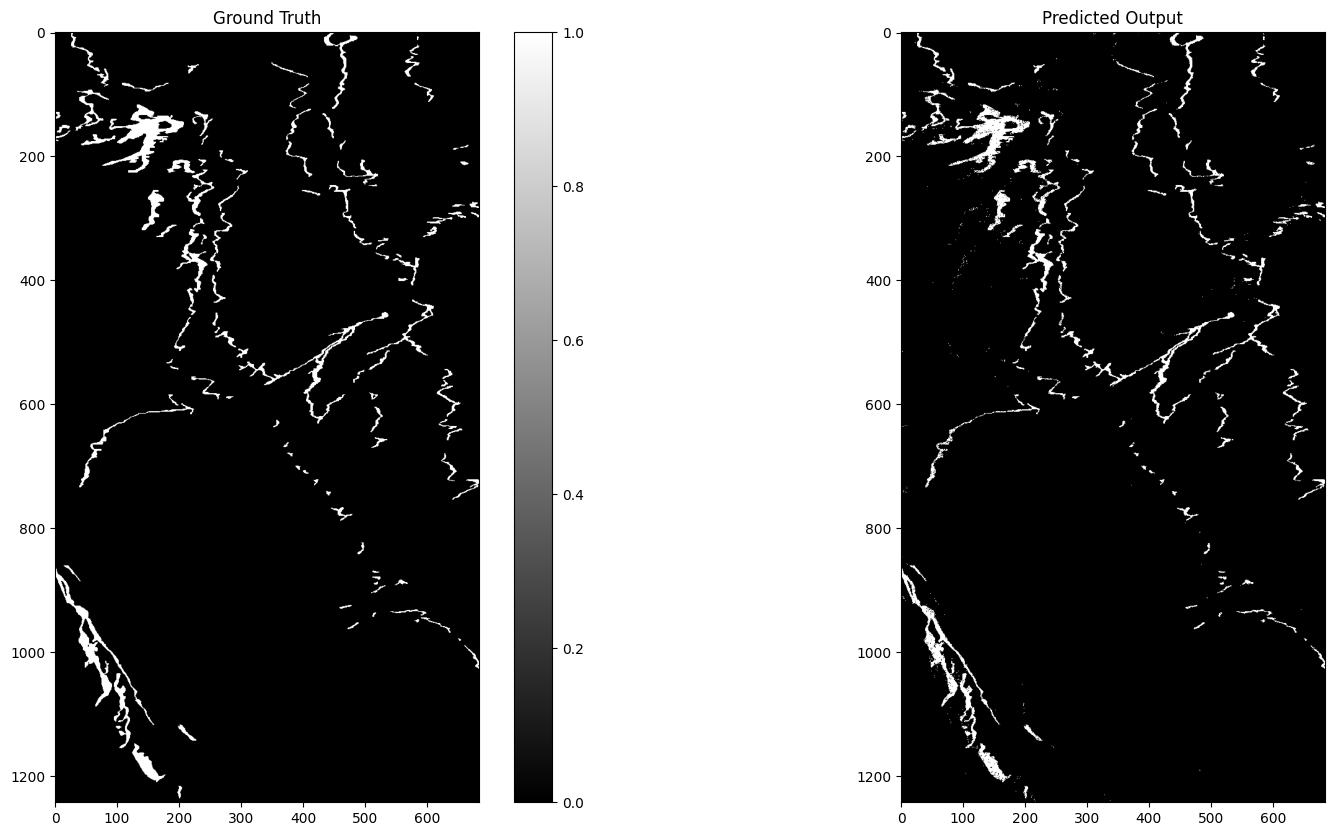

In [16]:
model_path = args.pretrained_model if args.pretrained_model else args.out
pcanet = load_model(os.path.join(model_path, "pcanet.pkl"))
classifier = load_model(os.path.join(model_path, "classifier.pkl"))

height,width = (1243,684)
outputs = np.zeros(height * width, dtype=int)

y_pred, y_test = test(pcanet, classifier, test_set)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

outputs[indices[0]] = train_set[1]
outputs[indices[1]] = y_pred

plt.figure(figsize=(20, 10))
mat = scipy.io.loadmat("/kaggle/input/content/GM01.mat")
gt = mat['map']
im = mat['img']
# Plot ground truth
plt.subplot(1, 2, 1)
plt.title("Ground Truth")
plt.imshow(gt, cmap="gray")
plt.colorbar()

# Plot predicted output
plt.subplot(1, 2, 2)
plt.title("Predicted Output")
plt.imshow(outputs.reshape(height,width), cmap="gray")